In [14]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

data = pd.read_csv('ev_battery_charging_data.csv')

In [15]:
data.describe()

,SOC (%),Voltage (V),Current (A),Battery Temp (°C),Ambient Temp (°C),Charging Duration (min),Degradation Rate (%),Efficiency (%),Charging Cycles,Optimal Charging Duration Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54.123090,3.854912,55.216515,29.807501,24.882106,69.846449,10.017067,97.996587,556.560000,1.194000
std,26.292363,0.204533,26.160678,5.729787,5.736199,28.919481,2.697141,0.539428,263.763052,0.747611
min,10.416882,3.502253,10.001047,20.013068,15.000614,20.618382,4.102433,96.791442,101.000000,0.000000
25%,31.237594,3.668752,33.521588,24.838015,19.899480,44.938000,8.010985,97.585509,317.750000,1.000000
50%,54.712664,3.863114,55.055253,29.685586,24.891962,69.040282,10.027301,97.994540,571.000000,1.000000
75%,76.988763,4.032326,78.319317,34.750816,29.799869,93.985178,12.072456,98.397803,786.000000,2.000000
max,99.974591,4.199590,99.803877,39.991154,34.954988,119.935030,16.042788,99.179513,999.000000,2.000000


# **DNN Model**

C:\Users\DELL\Anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Epoch 1/170
18/18 - 1s - loss: 49.5679 - mae: 49.7592 - val_loss: 37.5736 - val_mae: 37.7828 - lr: 0.0010 - 1s/epoch - 80ms/step
Epoch 2/170
18/18 - 0s - loss: 26.9660 - mae: 27.1812 - val_loss: 23.6188 - val_mae: 23.8530 - lr: 0.0010 - 114ms/epoch - 6ms/step
Epoch 3/170
18/18 - 0s - loss: 23.9269 - mae: 24.1773 - val_loss: 22.6937 - val_mae: 22.9528 - lr: 0.0010 - 114ms/epoch - 6ms/step
Epoch 4/170
18/18 - 0s - loss: 22.7348 - mae: 22.9998 - val_loss: 21.7605 - val_mae: 22.0335 - lr: 0.0010 - 109ms/epoch - 6ms/step
Epoch 5/170
18/18 - 0s - loss: 22.1320 - mae: 22.4056 - val_loss: 20.8832 - val_mae: 21.1574 - lr: 0.0010 - 110ms/epoch - 6ms/step
Epoch 6/170
18/18 - 0s - loss: 21.3195 - mae: 21.5957 - val_loss: 19.8053 - val_mae: 20.0779 - lr: 0.0010 - 125ms/epoch - 7ms/step
Epoch 7/170
18/18 - 0s - loss: 19.8735 - mae: 20.1418 - val_loss: 18.3844 - val_mae: 18.6426 - lr: 0.0010 - 110ms/epoch - 6ms/step
Epoch 8/170
18/18 - 0s - loss: 18.4558 - mae: 18.7114 - val_loss: 16.5163 - val_mae: 

Epoch 64/170
18/18 - 0s - loss: 2.8823 - mae: 3.0393 - val_loss: 0.7536 - val_mae: 0.8081 - lr: 1.5625e-05 - 142ms/epoch - 8ms/step
Epoch 65/170
18/18 - 0s - loss: 3.0571 - mae: 3.2145 - val_loss: 0.6965 - val_mae: 0.7287 - lr: 1.5625e-05 - 148ms/epoch - 8ms/step
Epoch 66/170
18/18 - 0s - loss: 3.1178 - mae: 3.2746 - val_loss: 0.7270 - val_mae: 0.7725 - lr: 1.5625e-05 - 150ms/epoch - 8ms/step
Epoch 67/170
18/18 - 0s - loss: 2.9086 - mae: 3.0663 - val_loss: 0.6959 - val_mae: 0.7296 - lr: 1.5625e-05 - 140ms/epoch - 8ms/step
Epoch 68/170
18/18 - 0s - loss: 3.1384 - mae: 3.2956 - val_loss: 0.6995 - val_mae: 0.7359 - lr: 1.5625e-05 - 143ms/epoch - 8ms/step
Epoch 69/170
18/18 - 0s - loss: 3.0463 - mae: 3.2011 - val_loss: 0.7116 - val_mae: 0.7479 - lr: 1.5625e-05 - 143ms/epoch - 8ms/step
Epoch 70/170
18/18 - 0s - loss: 2.9191 - mae: 3.0750 - val_loss: 0.7307 - val_mae: 0.7778 - lr: 1.5625e-05 - 160ms/epoch - 9ms/step
Epoch 71/170
18/18 - 0s - loss: 3.0248 - mae: 3.1853 - val_loss: 0.7461 - va

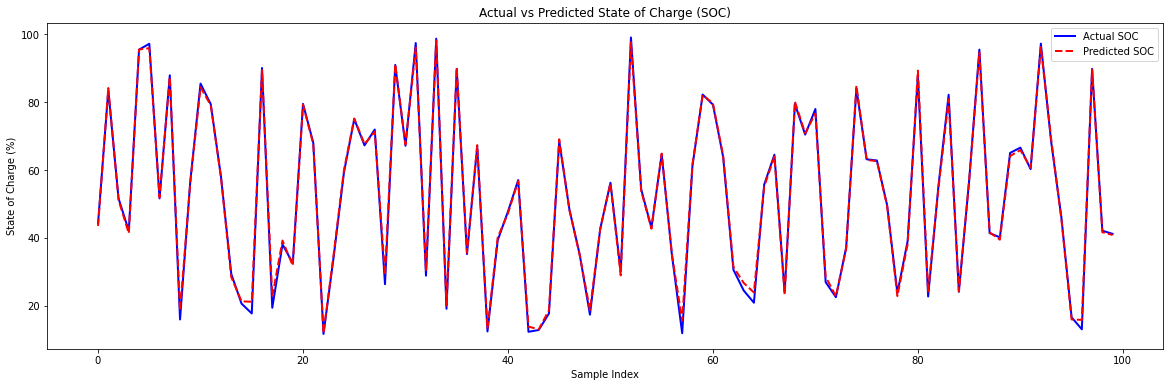

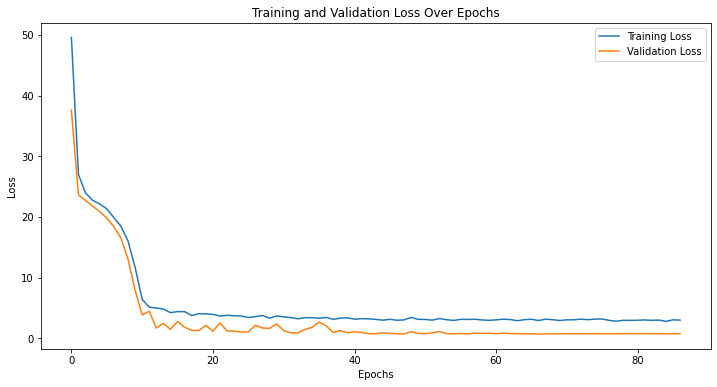

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Define features and target variable
# Use only the available columns in the dataset
features = data[['Voltage (V)', 'Current (A)', 'Battery Temp (°C)',
                 'Ambient Temp (°C)', 'Charging Duration (min)', 
                 'Degradation Rate (%)', 'Efficiency (%)']]
target = data['SOC (%)']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Normalize the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the DNN model
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-4)),  # First layer
    Dropout(0.2),  # Dropout to prevent overfitting
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),  # Second layer
    Dropout(0.3),  # Dropout to prevent overfitting
    Dense(128, activation='relu'),  # Third layer
    Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.Huber(),  # Huber loss for robustness to outliers
              metrics=['mae'])

# Define callbacks to optimize training
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Train the model
history = model.fit(X_train_scaled, y_train, validation_split=0.3, epochs=170, batch_size=32, verbose=2,
                    callbacks=[early_stopping, reduce_lr])

# Evaluate the model
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {loss}, Test Mean Absolute Error (MAE): {mae}')

# Predict on the test data
y_pred = model.predict(X_test_scaled)

# Visualize Actual vs Predicted SOC
plt.figure(figsize=(20, 6))
plt.plot(y_test.values[:100], label='Actual SOC', color='blue',linewidth=2)
plt.plot(y_pred[:100], label='Predicted SOC', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted State of Charge (SOC)')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (%)')
plt.legend()
plt.show()

# Visualize training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



# **LSTM model**

Epoch 1/200
18/18 - 19s - loss: 55.9797 - mae: 54.3812 - val_loss: 56.4500 - val_mae: 54.9564 - lr: 1.0000e-04 - 19s/epoch - 1s/step
Epoch 2/200
18/18 - 2s - loss: 55.7350 - mae: 54.3251 - val_loss: 56.1889 - val_mae: 54.8736 - lr: 1.0000e-04 - 2s/epoch - 94ms/step
Epoch 3/200
18/18 - 2s - loss: 55.4345 - mae: 54.1921 - val_loss: 55.8171 - val_mae: 54.6555 - lr: 1.0000e-04 - 2s/epoch - 113ms/step
Epoch 4/200
18/18 - 2s - loss: 54.9198 - mae: 53.8172 - val_loss: 55.0489 - val_mae: 54.0097 - lr: 1.0000e-04 - 2s/epoch - 107ms/step
Epoch 5/200
18/18 - 2s - loss: 53.6875 - mae: 52.6904 - val_loss: 53.0515 - val_mae: 52.0959 - lr: 1.0000e-04 - 2s/epoch - 94ms/step
Epoch 6/200
18/18 - 2s - loss: 50.4301 - mae: 49.4938 - val_loss: 47.8576 - val_mae: 46.9321 - lr: 1.0000e-04 - 2s/epoch - 95ms/step
Epoch 7/200
18/18 - 2s - loss: 43.1275 - mae: 42.1868 - val_loss: 38.5032 - val_mae: 37.5354 - lr: 1.0000e-04 - 2s/epoch - 102ms/step
Epoch 8/200
18/18 - 2s - loss: 34.0550 - mae: 33.0572 - val_loss: 

Epoch 62/200
18/18 - 2s - loss: 21.5540 - mae: 21.5407 - val_loss: 21.3759 - val_mae: 21.3690 - lr: 1.0000e-04 - 2s/epoch - 124ms/step
Epoch 63/200
18/18 - 2s - loss: 21.3230 - mae: 21.3184 - val_loss: 21.2526 - val_mae: 21.2474 - lr: 1.0000e-04 - 2s/epoch - 105ms/step
Epoch 64/200
18/18 - 2s - loss: 21.3963 - mae: 21.3894 - val_loss: 21.0465 - val_mae: 21.0385 - lr: 1.0000e-04 - 2s/epoch - 99ms/step
Epoch 65/200
18/18 - 2s - loss: 21.0126 - mae: 21.0014 - val_loss: 20.8536 - val_mae: 20.8404 - lr: 1.0000e-04 - 2s/epoch - 97ms/step
Epoch 66/200
18/18 - 2s - loss: 21.0410 - mae: 21.0256 - val_loss: 20.6955 - val_mae: 20.6824 - lr: 1.0000e-04 - 2s/epoch - 92ms/step
Epoch 67/200
18/18 - 2s - loss: 20.9239 - mae: 20.9073 - val_loss: 20.4306 - val_mae: 20.4108 - lr: 1.0000e-04 - 2s/epoch - 98ms/step
Epoch 68/200
18/18 - 2s - loss: 20.5874 - mae: 20.5645 - val_loss: 20.2021 - val_mae: 20.1753 - lr: 1.0000e-04 - 2s/epoch - 91ms/step
Epoch 69/200
18/18 - 2s - loss: 20.5168 - mae: 20.4906 - val

18/18 - 2s - loss: 4.4532 - mae: 4.0761 - val_loss: 1.9098 - val_mae: 1.4595 - lr: 1.2500e-05 - 2s/epoch - 84ms/step
Epoch 125/200
18/18 - 2s - loss: 4.2884 - mae: 3.9038 - val_loss: 1.9378 - val_mae: 1.4898 - lr: 1.2500e-05 - 2s/epoch - 86ms/step
Epoch 126/200
18/18 - 2s - loss: 4.4825 - mae: 4.1052 - val_loss: 1.9302 - val_mae: 1.4841 - lr: 1.2500e-05 - 2s/epoch - 86ms/step
Epoch 127/200
18/18 - 2s - loss: 4.7341 - mae: 4.3577 - val_loss: 1.9172 - val_mae: 1.4762 - lr: 1.2500e-05 - 2s/epoch - 90ms/step
Epoch 128/200
18/18 - 2s - loss: 4.5213 - mae: 4.1460 - val_loss: 2.0368 - val_mae: 1.6139 - lr: 1.2500e-05 - 2s/epoch - 100ms/step
Epoch 129/200
18/18 - 2s - loss: 4.4364 - mae: 4.0681 - val_loss: 1.8916 - val_mae: 1.4448 - lr: 1.2500e-05 - 2s/epoch - 96ms/step
Epoch 130/200
18/18 - 2s - loss: 4.3600 - mae: 3.9853 - val_loss: 1.8941 - val_mae: 1.4484 - lr: 1.2500e-05 - 2s/epoch - 92ms/step
Epoch 131/200
18/18 - 2s - loss: 4.3601 - mae: 3.9828 - val_loss: 1.8880 - val_mae: 1.4397 - lr:

Epoch 187/200
18/18 - 2s - loss: 4.2308 - mae: 3.8794 - val_loss: 1.7904 - val_mae: 1.3657 - lr: 1.5625e-06 - 2s/epoch - 97ms/step
Epoch 188/200
18/18 - 2s - loss: 4.2763 - mae: 3.9155 - val_loss: 1.7934 - val_mae: 1.3681 - lr: 1.5625e-06 - 2s/epoch - 88ms/step
Epoch 189/200
18/18 - 1s - loss: 4.4036 - mae: 4.0522 - val_loss: 1.7973 - val_mae: 1.3713 - lr: 1.5625e-06 - 1s/epoch - 83ms/step
Epoch 190/200
18/18 - 2s - loss: 4.1767 - mae: 3.8253 - val_loss: 1.7948 - val_mae: 1.3691 - lr: 1.5625e-06 - 2s/epoch - 85ms/step
Epoch 191/200
18/18 - 1s - loss: 4.3571 - mae: 4.0026 - val_loss: 1.7984 - val_mae: 1.3722 - lr: 1.5625e-06 - 1s/epoch - 83ms/step
Epoch 192/200
18/18 - 2s - loss: 4.3062 - mae: 3.9553 - val_loss: 1.7950 - val_mae: 1.3691 - lr: 1.5625e-06 - 2s/epoch - 84ms/step
Epoch 193/200
18/18 - 1s - loss: 4.1411 - mae: 3.7910 - val_loss: 1.7956 - val_mae: 1.3695 - lr: 1.0000e-06 - 1s/epoch - 82ms/step
Epoch 194/200
18/18 - 2s - loss: 4.2252 - mae: 3.8686 - val_loss: 1.8073 - val_mae:

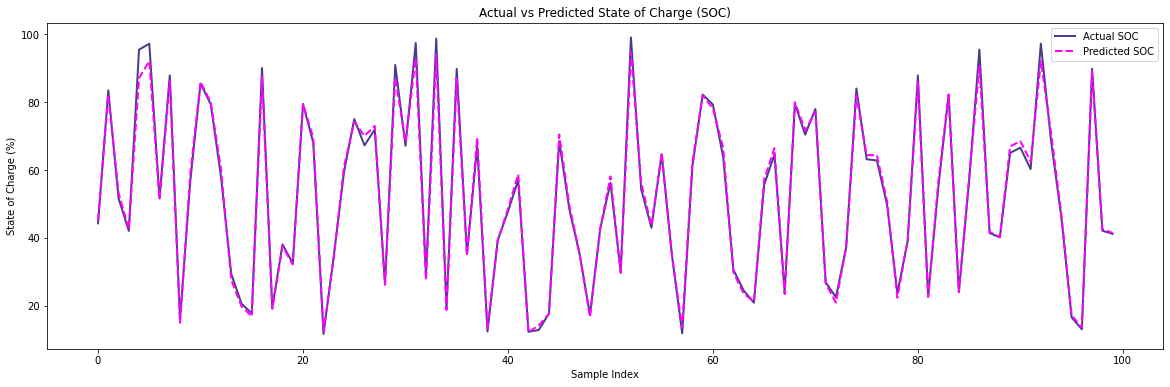

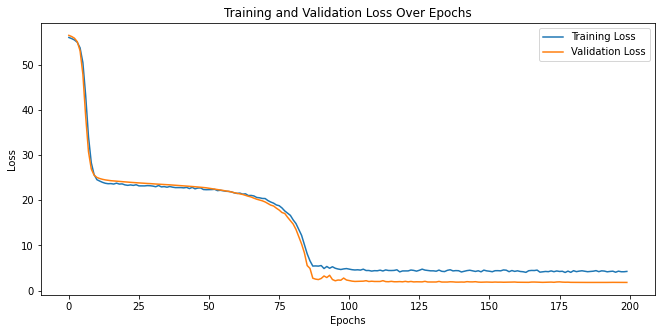

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


# Define features and target variable
features = data[['Voltage (V)', 'Current (A)', 'Battery Temp (°C)',
                 'Ambient Temp (°C)', 'Charging Duration (min)', 
                 'Degradation Rate (%)', 'Efficiency (%)']]
target = data['SOC (%)']


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Normalize the features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape data for LSTM [samples, timesteps, features]
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Build the LSTM model
model = Sequential([
    Bidirectional(LSTM(512, return_sequences=True, kernel_regularizer=l2(1e-3), input_shape=(1, X_train_scaled.shape[1]))),
    Dropout(0.4),
    
    Bidirectional(LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-3))),
    Dropout(0.4),
    
    Bidirectional(LSTM(128, kernel_regularizer=l2(1e-4))),
    Dropout(0.3),
    
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(1)   # Output layer for regression
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Fixed learning rate
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,min_lr=1e-6)

# Train the model
history = model.fit(
    X_train_reshaped, 
    y_train,
    validation_split=0.3,
    epochs=200,
    batch_size=32,
    verbose=2,
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate the model
loss, mae = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f'Test Loss: {loss}, Test Mean Absolute Error (MAE): {mae}')

# Predict on test data
y_pred = model.predict(X_test_reshaped)

# Visualize Actual vs Predicted SOC
plt.figure(figsize=(20, 6))
plt.plot(y_test.values[:100], label='Actual SOC', color='darkslateblue',linewidth=2)
plt.plot(y_pred[:100], label='Predicted SOC', color='fuchsia', linestyle='--',linewidth=2)
plt.title('Actual vs Predicted State of Charge (SOC)')
plt.xlabel('Sample Index')
plt.ylabel('State of Charge (%)')
plt.legend()
plt.show()

# Visualize training history
plt.figure(figsize=(11, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



# **XGBoost model**

Erreur Quadratique Moyenne MSE  : 20.2309
Racine de l'Erreur Quadratique Moyenne RMSE : 4.4979
Erreur Absolue Moyenne MAE  : 3.6336


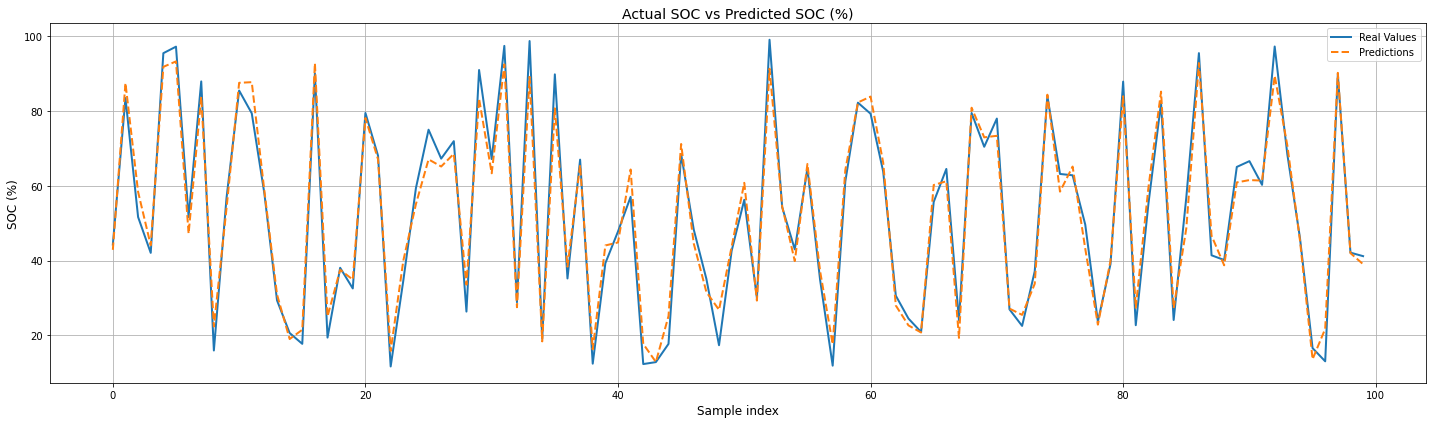

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1) Chargement et préparation des données
file_path = 'ev_battery_charging_data.csv'
data = pd.read_csv(file_path)

X = data.drop(columns=['SOC (%)'])
y = data['SOC (%)']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 2) Entraînement du modèle
model = XGBRegressor(objective='reg:squarederror',
                     n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3) Prédictions et calcul des métriques
pred = model.predict(X_test)
mse  = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, pred)

print(f"Erreur Quadratique Moyenne MSE  : {mse:.4f}")
print(f"Racine de l'Erreur Quadratique Moyenne RMSE : {rmse:.4f}")
print(f"Erreur Absolue Moyenne MAE  : {mae:.4f}")

# 4) Tracé des courbes
plt.figure(figsize=(20, 6))

# Limiter à 100 échantillons
y_test_limited = y_test.reset_index(drop=True)[:100]
pred_limited = pd.Series(pred).reset_index(drop=True)[:100]

# Tracer les courbes
plt.plot(
    y_test_limited,
    label='Real Values',
    linewidth=2)

plt.plot(
    pred_limited,
    label='Predictions',
    linestyle='--',
    linewidth=2
)


plt.title('Actual SOC vs Predicted SOC (%)', fontsize=14)
plt.xlabel('Sample index', fontsize=12)
plt.ylabel('SOC (%)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Epoch 1/170
18/18 - 1s - loss: 51.6676 - mae: 51.8600 - val_loss: 36.8761 - val_mae: 37.0945 - lr: 0.0010 - 1s/epoch - 76ms/step
Epoch 2/170
18/18 - 0s - loss: 28.8130 - mae: 29.0311 - val_loss: 26.7045 - val_mae: 26.9386 - lr: 0.0010 - 107ms/epoch - 6ms/step
Epoch 3/170
18/18 - 0s - loss: 24.6587 - mae: 24.9129 - val_loss: 21.9351 - val_mae: 22.1990 - lr: 0.0010 - 114ms/epoch - 6ms/step
Epoch 4/170
18/18 - 0s - loss: 23.1324 - mae: 23.3974 - val_loss: 21.9290 - val_mae: 22.1994 - lr: 0.0010 - 112ms/epoch - 6ms/step
Epoch 5/170
18/18 - 0s - loss: 22.2903 - mae: 22.5668 - val_loss: 22.1689 - val_mae: 22.4448 - lr: 0.0010 - 126ms/epoch - 7ms/step
Epoch 6/170
18/18 - 0s - loss: 21.3144 - mae: 21.5944 - val_loss: 21.7403 - val_mae: 22.0149 - lr: 0.0010 - 108ms/epoch - 6ms/step
Epoch 7/170
18/18 - 0s - loss: 20.6329 - mae: 20.9050 - val_loss: 19.3082 - val_mae: 19.5808 - lr: 0.0010 - 110ms/epoch - 6ms/step
Epoch 8/170
18/18 - 0s - loss: 19.2220 - mae: 19.4903 - val_loss: 18.3404 - val_mae: 

Epoch 64/170
18/18 - 0s - loss: 2.9972 - mae: 3.1444 - val_loss: 0.7530 - val_mae: 0.8333 - lr: 3.1250e-05 - 109ms/epoch - 6ms/step
Epoch 65/170
18/18 - 0s - loss: 2.7366 - mae: 2.8816 - val_loss: 0.7260 - val_mae: 0.7964 - lr: 3.1250e-05 - 109ms/epoch - 6ms/step
Epoch 66/170
18/18 - 0s - loss: 3.0184 - mae: 3.1722 - val_loss: 0.6347 - val_mae: 0.6345 - lr: 3.1250e-05 - 110ms/epoch - 6ms/step
Epoch 67/170
18/18 - 0s - loss: 3.1232 - mae: 3.2741 - val_loss: 0.6691 - val_mae: 0.7099 - lr: 3.1250e-05 - 111ms/epoch - 6ms/step
Epoch 68/170
18/18 - 0s - loss: 3.1420 - mae: 3.2947 - val_loss: 0.7855 - val_mae: 0.8768 - lr: 1.5625e-05 - 108ms/epoch - 6ms/step
Epoch 69/170
18/18 - 0s - loss: 3.1346 - mae: 3.2862 - val_loss: 0.7243 - val_mae: 0.7933 - lr: 1.5625e-05 - 109ms/epoch - 6ms/step
Epoch 70/170
18/18 - 0s - loss: 3.1429 - mae: 3.2968 - val_loss: 0.6399 - val_mae: 0.6637 - lr: 1.5625e-05 - 109ms/epoch - 6ms/step
Epoch 71/170
18/18 - 0s - loss: 3.0484 - mae: 3.1976 - val_loss: 0.6668 - va

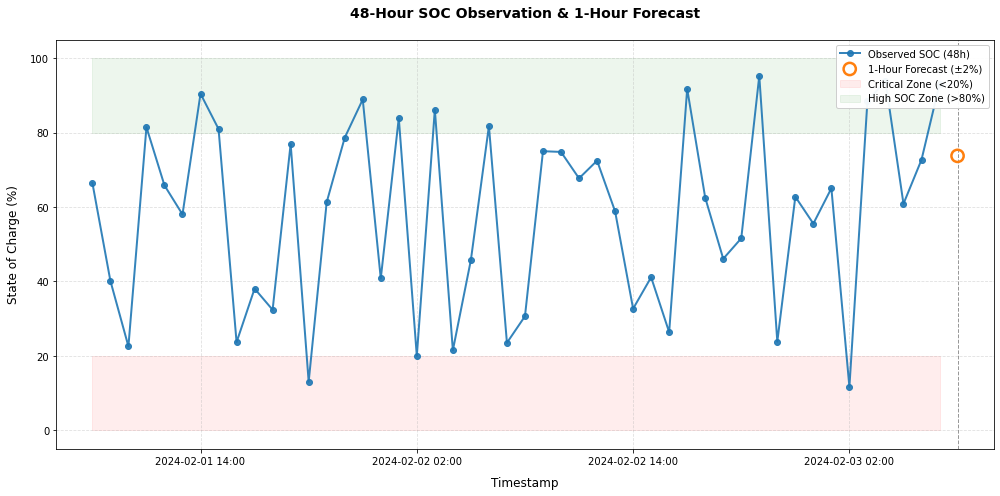

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load and prepare data
data = pd.read_csv('ev_battery_charging_data.csv')  # Replace with your data source

# Generate sequential timestamps (assuming hourly data)
start_time = pd.Timestamp('2024-01-01 00:00:00')
data['Timestamp'] = [start_time + pd.Timedelta(hours=i) for i in range(len(data))]
data = data.sort_values('Timestamp').reset_index(drop=True)

# Define features and target
features = data[['Voltage (V)', 'Current (A)', 'Battery Temp (°C)',
                 'Ambient Temp (°C)', 'Charging Duration (min)', 
                 'Degradation Rate (%)', 'Efficiency (%)']]
target = data['SOC (%)']

# Time-based train-test split (last 20% as test set)
split_idx = int(len(data) * 0.8)
X_train, X_test = features.iloc[:split_idx], features.iloc[split_idx:]
y_train, y_test = target.iloc[:split_idx], target.iloc[split_idx:]

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build DNN model
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1)
])

# Compile and train
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.Huber(),
              metrics=['mae'])

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.3, 
                    epochs=170, 
                    batch_size=32,
                    verbose=2,
                    callbacks=[early_stopping, reduce_lr])

# Evaluate and predict
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}, Test MAE: {mae:.4f}')
y_pred = model.predict(X_test_scaled)

# Prepare results dataframe
results_df = pd.DataFrame({
    'Timestamp': data.iloc[split_idx:]['Timestamp'].reset_index(drop=True),
    'Actual_SOC': y_test.values,
    'Forecast_SOC': y_pred.flatten()
})

# Get observed data (last 48 hours of TRAINING set)
observed = data.iloc[split_idx-48:split_idx]

# Get forecast data (first prediction in TEST set)
forecast_time = results_df['Timestamp'].iloc[0]
forecast_value = results_df['Forecast_SOC'].iloc[0]

# Create visualization
plt.figure(figsize=(14, 7))
ax = plt.gca()

# Plot observed data
plt.plot(observed['Timestamp'], observed['SOC (%)'],
         'o-', color='#1f77b4', linewidth=2, markersize=6,
         label='Observed SOC (48h)', alpha=0.9)

# Plot forecast point
plt.scatter(forecast_time, forecast_value, s=150, zorder=4,
           edgecolor='#ff7f0e', facecolor='none', linewidth=2.5,
           label='1-Hour Forecast (±2%)')

# Style adjustments
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
plt.xlim(observed['Timestamp'].iloc[0] - pd.Timedelta(hours=2),
         forecast_time + pd.Timedelta(hours=2))
plt.ylim(-5, 105)

# Critical zone shading
plt.fill_between(observed['Timestamp'], 20, 0, 
                 color='red', alpha=0.07, label='Critical Zone (<20%)')
plt.fill_between(observed['Timestamp'], 80, 100, 
                 color='green', alpha=0.07, label='High SOC Zone (>80%)')

plt.axvline(forecast_time, color='grey', linestyle='--', linewidth=1, alpha=0.8)
plt.title('48-Hour SOC Observation & 1-Hour Forecast\n', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp', fontsize=12, labelpad=10)
plt.ylabel('State of Charge (%)', fontsize=12, labelpad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.95)
plt.tight_layout()
plt.savefig('forecast_SOC.png')
plt.show()

In [23]:
print(f"{forecast_value:.2f}")

73.72
